In [3]:
import argparse
import functools
import itertools
import json
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from jaxtyping import Float
import pandas as pd
import tqdm
import plotly.graph_objects as go
from typing import List

# custom utils
from muutils.json_serialize import json_serialize
from muutils.parallel import run_maybe_parallel
from muutils.spinner import SpinnerContext

# pattern_lens
from pattern_lens.attn_figure_funcs import ATTENTION_MATRIX_FIGURE_FUNCS
from pattern_lens.consts import (
	DATA_DIR,
	DIVIDER_S1,
	DIVIDER_S2,
	SPINNER_KWARGS,
	ActivationCacheNp,
	AttentionMatrix,
)
from pattern_lens.indexes import (
	generate_functions_jsonl,
	generate_models_jsonl,
	generate_prompts_jsonl,
)
from pattern_lens.load_activations import load_activations
from pattern_lens.figures import HTConfigMock

In [ ]:
def compute_scalar_features(
	attn_batch: Float[torch.Tensor, "batch n_ctx n_ctx"],
) -> dict[str, Float[torch.Tensor, " batch"]]:
	diag_weight: Float[torch.Tensor, " batch"] = attn_batch.diagonal(0, dim1=-2, dim2=-1).mean(dim=-1)
	first_token_weight: Float[torch.Tensor, " batch"] = attn_batch[:, 0, :].mean(dim=-1)

	return dict(
		diag_weight=diag_weight,
		first_token_weight=first_token_weight,
	)


def scalar_features(
	models: list[str] = "pythia-14m,tiny-stories-1M,gpt2-small".split(","),
	save_path: Path = Path("../docs/temp"),
) -> pd.DataFrame:
	

	# output has cols:
	# model, prompt, layer_idx, head_idx, feature_name, feature_value
	output: list[dict] = list()

	for idx, model in enumerate(models):
		with SpinnerContext(message="setting up paths", **SPINNER_KWARGS):
			model_path: Path = save_path / model
			with open(model_path / "model_cfg.json", "r") as f:
				model_cfg = HTConfigMock.load(json.load(f))

		with SpinnerContext(message="loading prompts", **SPINNER_KWARGS):
			# load prompts
			with open(model_path / "prompts.jsonl", "r") as f:
				prompts: list[dict] = [json.loads(line) for line in f.readlines()]
			# truncate to n_samples
			prompts = prompts

		print(f"{len(prompts)} prompts loaded")

		for prompt in tqdm.tqdm(prompts, desc="prompts", total=len(prompts)):
			activations_path, cache = load_activations(
				model_name=model_cfg.model_name,
				prompt=prompt,
				save_path=save_path,
				return_fmt="numpy",
			)

			for key, head_batch in cache.items():
				features = compute_scalar_features(torch.tensor(head_batch[0]))
				for feature_name, feature_value in features.items():
					for head_idx in range(feature_value.shape[0]):
						output.append(
							dict(
								model=model,
								prompt=prompt["hash"],
								layer=idx,
								head=head_idx,
								feat_name=feature_name,
								feat_val=feature_value[head_idx].item(),
							)
						)

	return pd.DataFrame(output)


df = scalar_features()


✔️  (0.00s) setting up paths                                                   
✔️  (0.00s) loading prompts                                                    
64 prompts loaded


prompts: 100%|██████████| 64/64 [00:00<00:00, 83.28it/s]

| (0.00s) setting up paths                                                     

✔️  (0.00s) setting up paths                                                   
✔️  (0.00s) loading prompts                                                    
64 prompts loaded


prompts: 100%|██████████| 64/64 [00:04<00:00, 13.62it/s]

| (0.00s) setting up paths                                                     

✔️  (0.00s) setting up paths                                                   
✔️  (0.00s) loading prompts                                                    
78 prompts loaded


prompts: 100%|██████████| 78/78 [00:05<00:00, 14.77it/s]


In [23]:
df.to_json("scalar_features.jsonl", orient="records", lines=True)

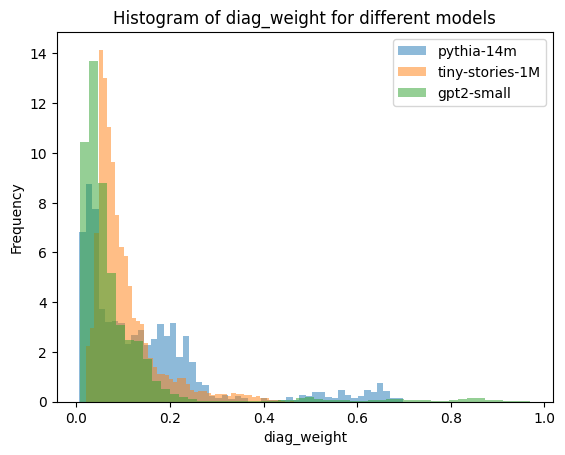

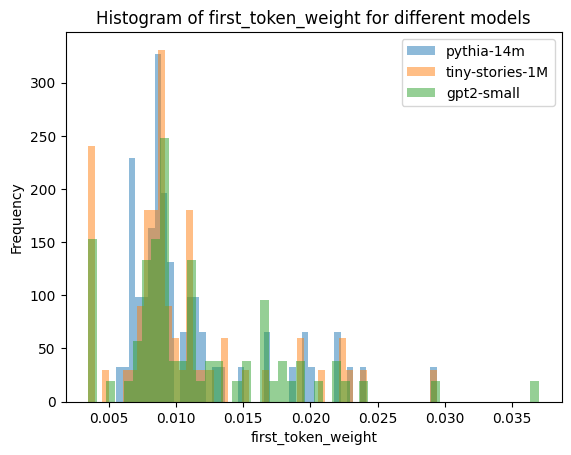

In [29]:
def plot_histograms_long(df: pd.DataFrame) -> None:
    """Plot histograms for each feature with different models superimposed.
    
    This function assumes the DataFrame is in long format with columns:
    "model", "feat_name", "feat_val", and optionally "prompt", "layer", "head".

    # Parameters:
     - `df : pd.DataFrame`
         DataFrame containing the data.
    
    # Returns:
     - `None`
         Displays the histograms.
    """
    features: list[str] = df["feat_name"].unique().tolist()
    models: list[str] = df["model"].unique().tolist()

    for feature in features:
        plt.figure()
        subset_feature: pd.DataFrame = df[df["feat_name"] == feature]
        for model in models:
            subset_model: pd.DataFrame = subset_feature[subset_feature["model"] == model]
            plt.hist(subset_model["feat_val"], bins=50, alpha=0.5, label=model, density=True)
        plt.xlabel(feature)
        plt.ylabel("Frequency")
        plt.title(f"Histogram of {feature} for different models")
        plt.legend()
        plt.show()


plot_histograms_long(df)

In [5]:


def load_jsonl(filepath: str) -> pd.DataFrame:
    """Load JSONL file into a DataFrame.
    
    # Parameters:
     - `filepath : str`
         Path to the JSONL file.
    
    # Returns:
     - `pd.DataFrame`
         DataFrame containing the JSONL data.
    """
    df: pd.DataFrame = pd.read_json(filepath, lines=True)
    return df

def load_and_aggregate(filepath: str, feat_name_filter: str = "diag_weight") -> pd.DataFrame:
    """Load JSONL data, inspect the first few rows, filter by a feature name, and compute aggregate statistics.
    
    Each line in the file should be a JSON object with at least the following keys:
      - "model"    : str
      - "layer"    : int
      - "head"     : int
      - "feat_name": str
      - "feat_val" : float
    
    The function prints the first few rows to let you inspect the data, filters the data to only include rows
    with `feat_name` equal to `feat_name_filter`, and then computes for each model, layer, and head the mean, 
    standard deviation, and count of the scalar values.
    
    # Parameters:
     - `filepath : str`
         Path to the JSONL file.
     - `feat_name_filter : str`
         The feature name to filter the data on (defaults to `"diag_weight"`).
    
    # Returns:
     - `pd.DataFrame`
         DataFrame with columns ["model", "layer", "head", "mean", "std", "count"].
    """
    df: pd.DataFrame = load_jsonl(filepath)
    print("First few rows of the data:")
    print(df.head())
    
    # Filter by the selected feature name.
    filtered_df: pd.DataFrame = df[df["feat_name"] == feat_name_filter]
    if filtered_df.empty:
        raise ValueError(f"No data found for feat_name == {feat_name_filter}")
    
    agg: pd.DataFrame = (
        filtered_df.groupby(["model", "layer", "head"])["feat_val"]
                   .agg(["mean", "std", "count"])
                   .reset_index()
    )
    return agg

def create_interactive_scatter(agg_df: pd.DataFrame) -> go.Figure:
    """Create an interactive scatterplot with a dropdown menu to select models.
    
    Each scatter point corresponds to a head/layer pair. The x-axis is the head index, the y-axis is the layer index.
    Marker color shows the mean value and marker size indicates the count.
    Hovering displays additional statistics.
    
    # Parameters:
     - `agg_df : pd.DataFrame`
         Aggregated DataFrame with columns ["model", "layer", "head", "mean", "std", "count"].
    
    # Returns:
     - `go.Figure`
         Interactive Plotly figure.
    """
    models: List[str] = sorted(agg_df["model"].unique().tolist())
    fig: go.Figure = go.Figure()
    
    # Create one scatter trace per model
    for model in models:
        model_data: pd.DataFrame = agg_df[agg_df["model"] == model]
        fig.add_trace(
            go.Scatter(
                x=model_data["head"],
                y=model_data["layer"],
                mode="markers",
                marker=dict(
                    size=np.log10(model_data["count"]) * 5,
                    color=model_data["mean"],
                    colorbar=dict(title="Mean Value"),
                    showscale=True,
                ),
                name=model,
                text=[
                    f"Std: {std_val:.2f}<br>Count: {cnt}" 
                    for std_val, cnt in zip(model_data["std"], model_data["count"])
                ],
                hovertemplate=(
                    "Head: %{x}<br>"
                    "Layer: %{y}<br>"
                    "Mean: %{marker.color:.2f}<br>"
                    "%{text}"
                ),
            )
        )
    
    # Create dropdown buttons so that only one model's trace is visible at a time.
    buttons: List[dict] = []
    for i, model in enumerate(models):
        visibility: List[bool] = [False] * len(models)
        visibility[i] = True
        buttons.append(
            dict(
                label=model,
                method="update",
                args=[
                    {"visible": visibility},
                    {"title": f"Distribution for model: {model}"}
                ],
            )
        )
    
    fig.update_layout(
        updatemenus=[
            dict(
                active=0,
                buttons=buttons,
                x=1.15,
                y=0.5,
            )
        ],
        title=f"Distribution for model: {models[0] if models else 'N/A'}",
        xaxis_title="Head",
        yaxis_title="Layer",
        template="plotly_white",
    )
    return fig

# Run the updated code using the uploaded file
filepath: str = "scalar_features.jsonl"
try:
    agg_df: pd.DataFrame = load_and_aggregate(filepath, feat_name_filter="diag_weight")
    fig: go.Figure = create_interactive_scatter(agg_df)
    fig.show()
except Exception as e:
    print(f"An error occurred: {e}")



First few rows of the data:
        model                  prompt  layer  head           feat_name  \
0  pythia-14m  MjWkadUxH4Z5nfLEFtUc1w      0     0         diag_weight   
1  pythia-14m  MjWkadUxH4Z5nfLEFtUc1w      0     1         diag_weight   
2  pythia-14m  MjWkadUxH4Z5nfLEFtUc1w      0     2         diag_weight   
3  pythia-14m  MjWkadUxH4Z5nfLEFtUc1w      0     3         diag_weight   
4  pythia-14m  MjWkadUxH4Z5nfLEFtUc1w      0     0  first_token_weight   

   feat_val  
0  0.169934  
1  0.251202  
2  0.042076  
3  0.151129  
4  0.008772  
